In [389]:
import xarray as xr
import pandas as pd
import numpy as np

uo = xr.open_dataset("../data/raw/adriatic_currents_uo_detided_2023_2024.nc")
vo = xr.open_dataset("../data/raw/adriatic_currents_vo_detided_2023_2024.nc")


# Generating RBF params

In [390]:
def get_test_train_val_ds_size(uo, vo):
    total_days = uo.time.size
    total_days_vo = vo.time.size
    assert total_days_vo == total_days

    train_end = int(0.70 * total_days) - 1
    test_end = int(0.85 * total_days) - 1
    val_end = int(total_days - 1)
    print(f"{train_end=}, {test_end=}, {val_end=}")
    return train_end, test_end, val_end


def split_data(var, train_end, test_end, val_end):
    return (
        var.isel(time=slice(0, train_end)),
        var.isel(time=slice(train_end, test_end)),
        var.isel(time=slice(test_end, val_end)),
    )

train_end, test_end, val_end = get_test_train_val_ds_size(uo, vo)

vo_train, vo_test, vo_val = split_data(vo, train_end, test_end, val_end)
uo_train, uo_test, uo_val = split_data(uo, train_end, test_end, val_end)

assert all(a.time.size == b.time.size for a, b in zip([uo_train, uo_test, uo_val],
                                                     [vo_train, vo_test, vo_val]))



train_end=510, test_end=620, val_end=730


In [391]:
def drop_na_and_marge(uo_sub, vo_sub):
    vo_sub = vo_sub[["longitude", "latitude", "vo_detided"]].to_dataframe()
    uo_sub = uo_sub[["longitude", "latitude", "uo_detided"]].to_dataframe()
    
    mask = (~vo_sub["vo_detided"].isna()) | (~uo_sub["uo_detided"].isna())
    vo_sub_filter = vo_sub[mask].reset_index() 
    uo_sub_filter = uo_sub[mask].reset_index()

    base_col = ["longitude", "latitude", "time"]
    assert (uo_sub_filter[base_col].to_numpy() == vo_sub_filter[base_col].to_numpy()).all()
 
    return pd.merge(
        uo_sub_filter, 
        vo_sub_filter, 
        on=base_col,
        # suffixes=('_uo', '_vo')
    )


train_df = drop_na_and_marge(uo_train, vo_train)
test_df = drop_na_and_marge(uo_test, vo_test)
val_df = drop_na_and_marge(uo_val, vo_val)

In [356]:
train_df.to_csv("train/dataframe.csv", index=False)
test_df.to_csv("test/dataframe.csv", index=False)
val_df.to_csv("val/dataframe.csv", index=False)


In [392]:
def creat_dict_map(train_df, test_df, val_df):    
    int_to_data_train = train_df["time"].drop_duplicates().to_dict()
    assert len(int_to_data_train) == train_end
    assert 0 in int_to_data_train
    assert train_end-1 in int_to_data_train

    int_to_data_test = test_df["time"].drop_duplicates().to_dict()
    assert len(int_to_data_test) == test_end - train_end
    assert 0 in int_to_data_train
    assert (test_end - train_end)-1 in int_to_data_test

    int_to_data_val = val_df["time"].drop_duplicates().to_dict()
    assert len(int_to_data_val) == val_end - test_end
    assert 0 in int_to_data_val
    assert (val_end - test_end)-1 in int_to_data_val
    return int_to_data_train, int_to_data_test, int_to_data_val

int_to_data_train, int_to_data_test, int_to_data_val = creat_dict_map(train_df, test_df, val_df)

In [393]:
import sys
import os
sys.path.append('..')
from model.RBFNetwork import RBFNetwork

def init_rbf(train_df, int_to_data_train):
    #init and learn RBF for first timestemp, use lerned centerls, and scaler for other timestemp
    mask_time_0 = train_df['time'] == int_to_data_train[0]
    time_0_rows = train_df[mask_time_0]

    x_day_0 = time_0_rows[["longitude", "latitude"]].to_numpy()
    y_day_0 = time_0_rows[["uo_detided", "vo_detided"]].to_numpy()

    rbf = RBFNetwork(spred=None, n_clusters=200)
    _, _ = rbf.train(x_day_0, y_day_0)
    return rbf

rbf = init_rbf(train_df, int_to_data_train)

Spred set to 0.44


In [ ]:
from multiprocessing import Pool
import multiprocessing as mp
from functools import partial
from tqdm import tqdm


def count_rbf_params(df, rbf_template, x):
    time = x[1]
    
    mask_df = df[df['time'] == time]
    rbf_x = mask_df[["longitude","latitude"]].to_numpy()
    rbf_y = mask_df[["uo_detided", "vo_detided"]].to_numpy()

    local_rbf = type(rbf_template)()  # Create new instance
    local_rbf.__dict__.update(rbf_template.__dict__)  # Copy attributes

    RMSE, R_sqer = local_rbf.train_for_fix_cluster_and_scaler(rbf_x, rbf_y)
    return time, np.hstack((local_rbf.model.coef_.flatten(), local_rbf.model.intercept_)), RMSE, R_sqer


def process_time_groups(time_items, df, rbf, process_name=""):
    print(f"Processing {len(time_items)} times for {process_name}...")
    
    # Create partial function with fixed arguments
    train_func = partial(count_rbf_params, df, rbf)
    
    with Pool(processes=mp.cpu_count()-2) as pool:
        print(f"Pool created with {mp.cpu_count()-2} processes")

        results = list(tqdm(pool.imap(train_func, time_items),
                            total=len(time_items), 
                            desc=process_name))
    
    time_to_coeff = {time: pars for time, pars, _, _ in results}
    time_to_metrics = {time: (RMSE, R_sqer) for time, _, RMSE, R_sqer in results}
    
    return time_to_coeff, time_to_metrics, results


train_time_to_coeff, train_time_to_metrics, train_results = process_time_groups(list(int_to_data_train.items()), train_df, rbf, process_name="training")
test_time_to_coeff, test_time_to_metrics, test_results = process_time_groups(list(int_to_data_test.items()), test_df, rbf, process_name="test")
val_time_to_coeff, val_time_to_metrics, val_results = process_time_groups(list(int_to_data_val.items()), val_df, rbf, process_name="val")

rbf

0.6071809451295769
0.6071809451295769
0.6071809451295769
0.6071809451295769
0.6071809451295769
0.6071809451295769
0.718415037469287
Processing 510 times for training...
Pool created with 18 processes


training:   0%|          | 0/510 [00:00<?, ?it/s]

In [ ]:
import pickle 

def save_rbf_params(time_to_coeff, time_to_metric, int_to_data, rbf, type="train"):

    os.makedirs(type, exist_ok=True)
    with open(f'{type}/time_to_coeff.pkl', 'wb') as f:
        pickle.dump(time_to_coeff, f)

    with open(f'{type}/time_to_metric.pkl', 'wb') as f:
        pickle.dump(time_to_metric, f)

    with open(f'{type}/int_to_data.pkl', 'wb') as f:
        pickle.dump(int_to_data, f)

    with open(f'rbf.pkl', 'wb') as f:
        pickle.dump(rbf, f)

# save_rbf_params(train_time_to_coeff, train_time_to_metrics, int_to_data_train, rbf, type="train")
# save_rbf_params(test_time_to_coeff, test_time_to_metrics, int_to_data_test, rbf, type="test")
# save_rbf_params(val_time_to_coeff, val_time_to_metrics, int_to_data_val, rbf, type="val")

# reading data and validation

In [157]:
import pickle 
import pickle 
import os
import xarray as xr
import pandas as pd
import numpy as np
import sys
import os
sys.path.append('..')
from model.RBFNetwork import RBFNetwork


def load_rbf_params(type="train"):
    with open(f'{type}/time_to_coeff.pkl', 'rb') as f:
        time_to_coeff = pickle.load(f)

    with open(f'{type}/time_to_metric.pkl', 'rb') as f:
        time_to_metric = pickle.load(f)

    with open(f'{type}/int_to_data.pkl', 'rb') as f:
        int_to_data = pickle.load(f)

    with open(f'rbf.pkl', 'rb') as f:
        rbf = pickle.load(f)

    return time_to_coeff, time_to_metric, int_to_data, rbf

train_time_to_coeff, train_time_to_metrics, int_to_data_train, rbf = load_rbf_params(type="train")
test_time_to_coeff, test_time_to_metrics, int_to_data_test, rbf_ = load_rbf_params(type="test")
val_time_to_coeff, val_time_to_metrics, int_to_data_val, rbf_ = load_rbf_params(type="val")

train_df = pd.read_csv("train/dataframe.csv")
test_df = pd.read_csv("test/dataframe.csv")
val_df = pd.read_csv("val/dataframe.csv")

# rbf = init_rbf(train_df, int_to_data_train)


In [271]:
# train_time_to_coeff[int_to_data_train[0]]

In [394]:
train_df[train_df["time"] == int_to_data_train[0]]
# TODO shoud give an output 

,longitude,latitude,time,uo_detided,vo_detided
0,12.000000,40.020832,2023-01-01,0.017013,-0.066594
510,12.000000,40.062500,2023-01-01,0.007997,-0.070341
1020,12.000000,40.104168,2023-01-01,0.052729,-0.025742
1530,12.000000,40.145832,2023-01-01,0.080127,0.041475
2040,12.000000,40.187500,2023-01-01,0.126955,0.085765
...,...,...,...,...,...
5429460,19.708334,40.104168,2023-01-01,-0.010563,0.022728
5429970,19.750000,40.020832,2023-01-01,-0.046849,0.017134
5430480,19.750000,40.062500,2023-01-01,-0.000598,0.014129
5430990,19.791666,40.020832,2023-01-01,-0.033584,0.026101


In [395]:
int_to_data_train[0]

Timestamp('2023-01-01 00:00:00')

In [396]:
train_df["time"]

0         2023-01-01
1         2023-01-02
2         2023-01-03
3         2023-01-04
4         2023-01-05
             ...    
5432005   2024-05-20
5432006   2024-05-21
5432007   2024-05-22
5432008   2024-05-23
5432009   2024-05-24
Name: time, Length: 5432010, dtype: datetime64[ns]

In [397]:
lat_lon = train_df[train_df["time"] == int_to_data_train[7]][["longitude", "latitude"]].to_numpy()
X = rbf._compute_rbf_activations(lat_lon, rbf.cluster_centers)

In [398]:
first_batch_true = train_time_to_coeff[int_to_data_train[7]]
W_true = first_batch_true[:2*rbf.n_clusters].reshape((-1, 200)) #
B_true = first_batch_true[2*rbf.n_clusters:]
Y_pred_tru = (X @ W_true.T) + B_true

In [399]:
from sklearn.metrics import r2_score

r2_values = r2_score(train_df[train_df["time"] == int_to_data_train[7]][["uo_detided", "vo_detided"]].to_numpy(), Y_pred_tru)
print("check is r2 is the same", r2_values, train_time_to_metrics[int_to_data_train[7]][1])

check is r2 is the same 0.6821935620311914 0.6821935620311914


## Train

In [419]:
normalized = False
only_for_first_batch = True
seq_length = 7
batch_size = 4
number_of_epoch = 10000

#LSTM pars
n_clusters = rbf.n_clusters
bias = 2
W_size = 2 * n_clusters
input_size= W_size + bias 
hidden_size=512
num_layers=2
output_size= W_size + bias

In [420]:
import torch

# potential bug
def create_sequences(data, int_to_data, seq_length=7):
    x, y = [], []
    for i in range(len(data) - seq_length):
        xs = [data[int_to_data[i+j]] for j in range(seq_length)]
        x.append(xs)
        y.append(data[int_to_data[i + seq_length]])
    return torch.from_numpy(np.array(x)).float(), torch.from_numpy(np.array(y)).float()


X_tensor, y_tensor  = create_sequences(train_time_to_coeff, int_to_data_train, seq_length=seq_length)

In [421]:
if normalized:
    combined_tensor = torch.cat([X_tensor.flatten(), y_tensor.flatten()])

    # Calculate mean and standard deviation
    mean = combined_tensor.mean()
    std = combined_tensor.std()
    
    # Avoid division by zero by adding small epsilon if needed
    if std == 0:
        std = 1e-8

    # Standardize the tensors
    X_standardized = (X_tensor - mean) / std
    y_standardized = (y_tensor - mean) / std

    print("Original X range:", X_tensor.min().item(), X_tensor.max().item())
    print("Original y range:", y_tensor.min().item(), y_tensor.max().item())
    print("Standardized X mean:", X_standardized.mean().item(), "std:", X_standardized.std().item())
    print("Standardized y mean:", y_standardized.mean().item(), "std:", y_standardized.std().item())

    X_tensor = X_standardized
    y_tensor = y_standardized


In [422]:
import torch
from torch.utils.data import Dataset, DataLoader

class SeaCurrentDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_dataset = SeaCurrentDataset(X_tensor, y_tensor)

In [423]:
loader = DataLoader(train_dataset, batch_size=batch_size)

In [424]:
import torch.nn as nn


class LSTM(nn.Module):
    def __init__(self, input_size=402, hidden_size=512, num_layers=2, output_size=402):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out



In [425]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Use device: {device}")

Use device: cpu


In [ ]:
model = LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, output_size=output_size).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# caching X, lat_lon the same for eny time
lat_lon = train_df[train_df["time"] == int_to_data_train[7]][["longitude", "latitude"]].to_numpy()
X = rbf._compute_rbf_activations(lat_lon, rbf.cluster_centers)

loss_history = []
r2_for_lstm_history = []
r2_for_uv_history = []
true_r2_for_uv_history = []

for epoch in range(number_of_epoch):
    model.train()

    # Train on the same single batch every epoch
    for i_batch, (X_batch, y_batch) in enumerate(loader):
        if only_for_first_batch and i_batch >= 1:  # only for first batch
            break
        
        X_batch = X_batch.to(device)#.float()
        y_batch = y_batch.to(device)#.float()
        
        y_pred_batch = model(X_batch)
        loss = loss_fn(y_pred_batch, y_batch) # Are shape correct?
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        #evaluation 
        if epoch%100==0:
            model.eval()
            with torch.no_grad():
                loss_history.append(loss.item())
                
                y_batch_numpy = y_batch.detach().numpy().reshape(-1)
                y_pred_batch_numpy = y_pred_batch.detach().numpy().reshape(-1)
                
                r2_for_lstm = r2_score(y_batch_numpy, y_pred_batch_numpy)
                r2_for_lstm_history.append(r2_for_lstm)
                
                #count R2 for u, v see
                r2_for_uv_batch = []
                ground_true_r2_for_uv_batch = []


                if normalized:
                    y_pred_batch = y_pred_batch * std + mean

                W_all = y_pred_batch[:, :W_size].cpu().numpy().reshape(-1, 2, n_clusters)
                B_all = y_pred_batch[:, W_size:].cpu().numpy()

                for i_y_pred in range(len(y_pred_batch)):
                    W = W_all[i_y_pred]  # Shape: (2, n_clusters)
                    B = B_all[i_y_pred]  # Shape: (2,)
                    
                    # Vectorized UV prediction
                    uv_pred = (X @ W.T) + B

                    date_int = (i_batch*seq_length) + i_y_pred + seq_length 
                    pred_time_seq = train_df["time"] == int_to_data_train[date_int]  # i_batch, batch_size, seq_len
                    uv_true = train_df[pred_time_seq][["uo_detided", "vo_detided"]].to_numpy()
                    
                    r2_values_uv = r2_score(uv_true, uv_pred)
                    r2_for_uv_batch.append(r2_values_uv)
                
                    ground_true_r2_for_uv = train_time_to_metrics[int_to_data_train[date_int]][1]
                    ground_true_r2_for_uv_batch.append(ground_true_r2_for_uv)

                avg_r2_uv = np.mean(r2_for_uv_batch)
                avg_true_r2_uv = np.mean(ground_true_r2_for_uv_batch)
                
                r2_for_uv_history.append(avg_r2_uv)
                true_r2_for_uv_history.append(avg_true_r2_uv)

                print(f'Epoch {epoch+1}, Loss: {loss.item():.6f}')
                print(f'Epoch {epoch+1}, R2 for parameters: {r2_for_lstm}')
                print(f'Epoch {epoch+1}, R2 for u and v (whole batch avg): {avg_r2_uv}')
                print(f'Expected, R2 for u and v: {avg_true_r2_uv}')
            
            model.train()  # Switch back to training mode
        

Epoch 1, Loss: 324.570007
Epoch 1, R2 for parameters: 0.00014132261276245117
Epoch 1, R2 for u and v (whole batch avg): -4.072780443344485
Expected, R2 for u and v: 0.7388573167480985
Epoch 101, Loss: 68.312698
Epoch 101, R2 for parameters: 0.7895583510398865
Epoch 101, R2 for u and v (whole batch avg): -246.0499904132006
Expected, R2 for u and v: 0.7388573167480985
Epoch 201, Loss: 51.753212
Epoch 201, R2 for parameters: 0.8405709266662598
Epoch 201, R2 for u and v (whole batch avg): -163.38340403577755
Expected, R2 for u and v: 0.7388573167480985
Epoch 301, Loss: 47.281307
Epoch 301, R2 for parameters: 0.8543468713760376
Epoch 301, R2 for u and v (whole batch avg): -78.01251003203176
Expected, R2 for u and v: 0.7388573167480985
Epoch 401, Loss: 45.380577
Epoch 401, R2 for parameters: 0.8602021932601929
Epoch 401, R2 for u and v (whole batch avg): -44.766283174315966
Expected, R2 for u and v: 0.7388573167480985
Epoch 501, Loss: 43.933743
Epoch 501, R2 for parameters: 0.864659309387207

In [ ]:
print("Does overfitting get sucess? Are pred r2 for uv simmilar to r2 for uv ground true?")

l = [train_time_to_metrics[int_to_data_train[i+seq_length]][1] for i in range(batch_size)]
print(f"predicted uv r2: {sum(l)/len(l)}")
print(f"ground true uv r2: {r2_for_uv_history[-1]}")

Does overfitting get sucess? Are pred r2 for uv simmilar to r2 for uv ground true?
0.7388573167480985
ground true uv r2: -1086.0784768121055


In [409]:
print("Does overfitting get sucess? Are pred wieight the same as ground true wight?")
for i in range(batch_size):
    y_pred = y_pred_batch[i]
    if normalized:
        y_pred = y_pred * std + mean
    print(np.allclose(y_pred.detach().numpy(), train_time_to_coeff[int_to_data_train[i + 7]], atol=1e-1))


Does overfitting get sucess? Are pred wieight the same as ground true wight?
True
True
True
True


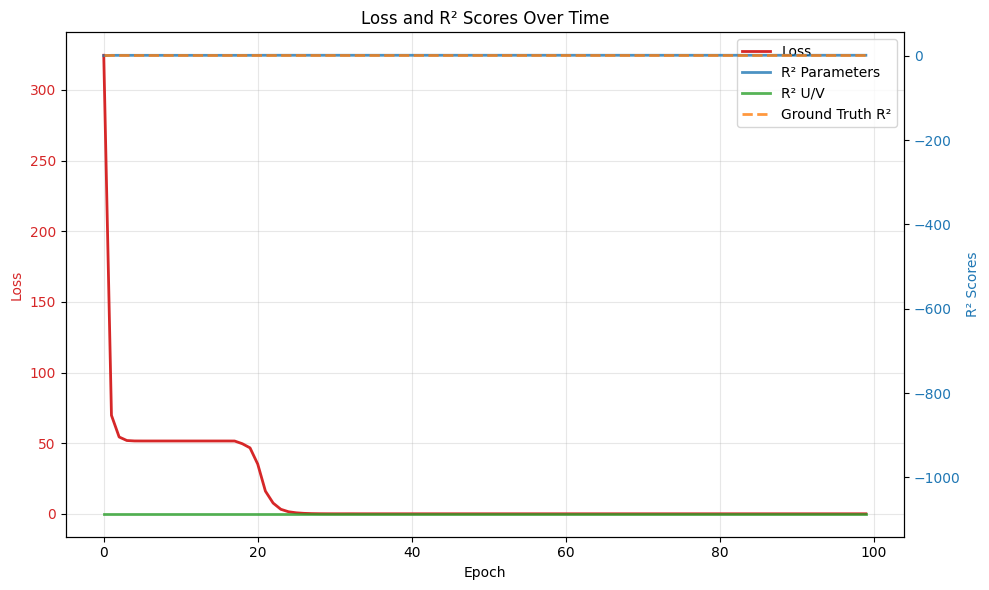

In [410]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot loss on left y-axis
color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color=color)
ax1.plot(loss_history, color=color, label='Loss', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Create second y-axis for R² scores on the right
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('R² Scores', color=color)
line1 = ax2.plot(r2_for_lstm_history, color=color, label='R² Parameters', linewidth=2, alpha=0.8)
line2 = ax2.plot(r2_for_uv_history, color='tab:green', label='R² U/V', linewidth=2, alpha=0.8)
line3 = ax2.plot(true_r2_for_uv_history, color='tab:orange', label='Ground Truth R²', linewidth=2, linestyle='--', alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color)

# Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')


plt.title('Loss and R² Scores Over Time')
plt.tight_layout()
plt.show()